# IMPORTS & UTILITIES

## IMPORTS 

In [9]:
import numpy as np
import plotly.graph_objs as go
import matplotlib.pyplot as plt
import os
import cv2
import csv
from IPython.display import Video

from perlin_noise import PerlinNoise
noise = PerlinNoise(seed=42)

import random
random.seed(42)

## CHECKERS

In [10]:
def check_column(matrix):
    '''
    raise error if given object is not a column
    i.e. a matrix nx1
    '''
    if not (isinstance(matrix, np.ndarray) and matrix.shape == (3, 1)):
        raise InvalidVector(f"{matrix.shape} is invalid column vector")
    
    return matrix    
    
class InvalidVector(Exception):
    '''
    custom exception
    '''
    def __init__(self, message):
        self.message = message
        super().__init__(self.message)

## FILES MANIPOLATION

In [11]:
def save_video(name, array_frame, fps=2):    
    '''
    save an array of plots as mp4 
    '''
    height, width, _ = array_frame[0].shape
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    video = cv2.VideoWriter(name, fourcc, fps, (width, height))

    for frame in array_frame:
        video.write(frame)

    video.release()
    return name

def frames(full_history, step=100,remove=True):
    '''
    given arrays, compute the plots for the mp4 file
    '''
    output_dir = "../imgs"
    os.makedirs(output_dir, exist_ok=True)

    history = np.array(full_history).copy()[::step]
    images = []

    lim_x = np.max(np.abs([[_.spaceship.position[0, 0] for _ in history], 
                            [_.moon.position[0, 0] for _ in history]]))
    lim_y = np.max(np.abs([[_.spaceship.position[1, 0] for _ in history], 
                            [_.moon.position[1, 0] for _ in history]]))
    lim_z = np.max(np.abs([[_.spaceship.position[2, 0] for _ in history], 
                            [_.moon.position[2, 0] for _ in history]]))
    trace_spaceship = 100 

    N = len(history)

    for i in range(N):
        print(f"{str(round(i / N * 100, 3))} % ")
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')

        land = history[i].spaceship.position
        ax.scatter(land[0], land[1], land[2], color='r', label='Spaceship (current position)', s=50)

        for j in range(max(0, i*step - trace_spaceship), i*step):
            alpha = 0.3 
            past_land = full_history[j].spaceship.position
            ax.scatter(past_land[0], past_land[1], past_land[2], color='r', alpha=alpha, s=10)

        moon = history[i].moon.position
        ax.scatter(moon[0], moon[1], moon[2], color='b', label='Moon (current position)', s=50)

        ax.set_xlim(lim_x, -lim_x)
        ax.set_ylim(lim_y, -lim_y)
        ax.set_zlim(lim_z, -lim_z)
        
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_zlabel('')

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

        ax.set_title(f"Time: {str(round(i * Simulation.delta_T * step, 2))}")
        ax.legend()

        filename = f"{output_dir}/{i}.png"
        plt.savefig(filename)
        plt.close(fig)

        image = cv2.imread(filename)
        images.append(image)

        if remove:
            os.remove(filename)
        
    return images


### SAVE (NOISY) STATES 

In [12]:
def save_states(data,file_name):
    '''
    save real-states of the model as csv files
    '''
    with open(file_name, 'w', newline='') as file:
        writer = csv.writer(file)
        for state in data:
            writer.writerow(state.flatten())

    print(f"States saved as rows in '{file_name}'\n")

def add_noise(real_data):
    '''
    given an array of states, add some noise to it
    '''
    random.seed(42)
    return np.array([
        data + np.array([random.normalvariate(0, 1000) for i in range(len(data))]).reshape(-1, 1)
        for data in real_data
    ])

## PLOTS



In [13]:
def show_plots(raw_data):
    '''
    describe the array of states with plots    
    '''
    # Create a 3x1 grid of subplots
    fig, axs = plt.subplots(3, 1, figsize=(15, 8))
    domain = [i * Simulation.delta_T for i in range(len(raw_data))]

    # Extract data from raw_data
    position_x = [data[0, 0] for data in raw_data]
    position_y = [data[1, 0] for data in raw_data]
    position_z = [data[2, 0] for data in raw_data]

    velocity_x = [data[3, 0] for data in raw_data]
    velocity_y = [data[4, 0] for data in raw_data]
    velocity_z = [data[5, 0] for data in raw_data]

    acceleration_x = [data[6, 0] for data in raw_data]
    acceleration_y = [data[7, 0] for data in raw_data]
    acceleration_z = [data[8, 0] for data in raw_data]

    # Plot 1: Position (x, y, z)
    axs[0].plot(domain, position_x, label="Position x")
    axs[0].plot(domain, position_y, label="Position y")
    axs[0].plot(domain, position_z, label="Position z")
    axs[0].set_title('Position')
    axs[0].legend()
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Position')

    # Plot 2: Velocity (x, y, z)
    axs[1].plot(domain, velocity_x, label="Velocity x")
    axs[1].plot(domain, velocity_y, label="Velocity y")
    axs[1].plot(domain, velocity_z, label="Velocity z")
    axs[1].set_title('Velocity')
    axs[1].legend()
    axs[1].set_xlabel('Time (s)')
    axs[1].set_ylabel('Velocity')

    # Plot 3: Acceleration (x, y, z)
    axs[2].plot(domain, acceleration_x, label="Acceleration x")
    axs[2].plot(domain, acceleration_y, label="Acceleration y")
    axs[2].plot(domain, acceleration_z, label="Acceleration z")
    axs[2].set_title('Acceleration')
    axs[2].legend()
    axs[2].set_xlabel('Time (s)')
    axs[2].set_ylabel('Acceleration')

    # Adjust layout for better spacing
    plt.tight_layout()

    # Show the plot
    plt.show()

def show_noise(spaceship_positions):
        # Generate a linear gradient for colors
        num_points = len(spaceship_positions)
        colors = np.linspace(0,0.01*num_points, num_points)  # Values from 0 to 1 for color mapping
        color_scale = 'inferno'  # Choose a color scale (e.g., 'Viridis', 'Cividis', etc.)

        # Plot all spaceship points
        spaceship_trace = go.Scatter3d(
            x=spaceship_positions[:,0,0],  # X-coordinates
            y=spaceship_positions[:,1,0],  # Y-coordinates
            z=spaceship_positions[:,2,0],  # Z-coordinates
            mode='markers',
            marker=dict(
                size=1,
                color=colors,
                colorscale=color_scale,
                showscale=True  # No color bar for spaceship points
            ),
            name='spaceship'
        )

        # Create the layout
        layout = go.Layout(
            scene=dict(
                aspectmode="data"
            ),
            title="Spaceship Trajectory (measured with noise)",
        )

        # Create the figure and display it
        fig = go.Figure(data=[spaceship_trace], layout=layout)
        fig.show()   


# SIMPLIFIED GRAVITATIONAL MODEL

In [14]:
class Simulation():
    '''
    Describe a collection of models
    i.e. a sequence of frames
    '''
    delta_T = 0.01
    G_constant = 1#6.67430e-11
    boundary = 1000

    NO_RESULT = "orbiting"
    COLLISION = "collision"
    MISSED = "missed"
    
    def __init__(self,model):
        self.current = model
        self.history = []

        self.result = Simulation.NO_RESULT

    def update(self):
        '''
        Add the new model to the collection
        If needed, the simulation stop iterating
        '''
        self.history.append(self.current)
        prev = self.current
        self.current = self.current.get_next_state()

        if Simulation.check_collision(prev,self.current):
            self.result = Simulation.COLLISION
        elif Simulation.check_missed(prev,self.current):
           self.result = Simulation.MISSED
        else:  
            self.result = Simulation.NO_RESULT
        
        return self.result
    
    def check_collision(prev_model, next_model):
        '''
        Check if the spaceship collide with the moon
        '''
        #TODO verify if the line from pos_spaceship(t)->pos_spaceship(t+1) collide with the moon

        dist=np.linalg.norm(next_model.moon.position-next_model.spaceship.position)
        return dist <= Moon.radius
        
    
    def check_missed(prev_model, next_model):
        '''
        check if the distance from the moon and the spaceship became too big
        i.e. they missed the collision
        '''

        dist=np.linalg.norm(next_model.moon.position-next_model.spaceship.position)

        return dist >= Simulation.boundary
        

        
    def evaluate_prediction(simulation,depth=1000000):
        '''
        Compute the models in the collection
        stops after depths iterations or when it ends
        '''
        for i in range(depth):
            result = simulation.update()
            if result != Simulation.NO_RESULT:
                break

        return simulation.result
        
    
    def animate_static(history): 
        '''
        3d plot describing the position of the spaceship
        '''  

        # Extract positions and prepare for plotting
        moon_positions = np.array([model.moon.position for model in history])  # Transpose to (3, n)
        spaceship_positions = np.array([model.spaceship.position for model in history])  # Transpose to (3, n)


        # Generate a linear gradient for colors
        num_points = len(history)
        colors = np.linspace(0, 1, num_points)  # Values from 0 to 1 for color mapping
        color_scale = 'Inferno' 

        # Plot all moon points
        moon_trace = go.Scatter3d(
            x=moon_positions[:,0,0],  # X-coordinates
            y=moon_positions[:,1,0],  # Y-coordinates
            z=moon_positions[:,2,0],  # Z-coordinates
            mode='markers',
            marker=dict(
                size=5,
                color=colors,
                colorscale=color_scale,
                showscale=False  # Adds a color bar for reference
            ),
            name='Moon'
        )

        # Plot all spaceship points
        spaceship_trace = go.Scatter3d(
            x=spaceship_positions[:,0,0],  # X-coordinates
            y=spaceship_positions[:,1,0],  # Y-coordinates
            z=spaceship_positions[:,2,0],  # Z-coordinates
            mode='markers',
            marker=dict(
                size=1,
                color=colors,
                colorscale=color_scale,
                showscale=True  # No color bar for spaceship points
            ),
            name='spaceship'
        )

        # Create the layout
        layout = go.Layout(
            scene=dict(
                aspectmode="data"
            ),
            title="Moon and spaceship Trajectory",
        )

        # Create the figure and display it
        fig = go.Figure(data=[moon_trace, spaceship_trace], layout=layout)
        fig.show()


In [15]:
class Model:
    '''
    Describe a real-world state of a given instant
    '''
    def __init__(self,moon,spaceship,time=0):
        self.moon = moon
        self.spaceship = spaceship
        self.time = time
        self.prediction = None

    def get_global_state(self):
        '''
        Return a numpy array containing all information about the current state
        '''
        return np.concatenate([
                self.moon.get_state(),
                self.spaceship.get_state()
            ], axis=0)
        
    def get_next_state(self):
        '''
        By delegating, create the next frame
        '''     
        return Model(
            self.moon.get_next_state(self),
            self.spaceship.get_next_state(self),
            self.time + Simulation.delta_T
        )

    

In [16]:
class Moon:
    '''
    Object moving with constant speed in 3 dimensions
    '''
    radius = 13.5#1737400 
    mass = 2000#7.347e22
    
    def __init__(self,
        position =  np.array([[0,0,0]]).T,
        velocity =  np.array([[0,0,0]]).T,
    ):      
        self.position = check_column(position)
        self.velocity = check_column(velocity)
    
    def get_state(self):
        '''
        summarize the state as a column vector
        '''
        return np.concatenate([
                self.position,
                self.velocity
            ], axis=0)
        
    def get_next_state(self,model):
        '''
        Predict the next state of the object
        '''
        return Moon(
            self.position + self.velocity * Simulation.delta_T,
            self.velocity
        )

In [17]:
class Spaceship:
    '''
    Object moving with acceleration updated by gravitational pull
    '''
    mass = 1#15000
    def __init__(self,
        position     =  np.array([[0,0,0]]).T,
        velocity     =  np.array([[0,0,0]]).T,
        acceleration =  np.array([[0,0,0]]).T,
    ):      
        self.position = check_column(position)
        self.velocity = check_column(velocity)
        self.acceleration = check_column(acceleration)
    
    def get_state(self):
        '''
        summarize the state as a column vector
        '''
        return np.concatenate([
                self.position,
                self.velocity,
                self.acceleration
            ], axis=0)
        
    def get_moon_pull(self,model):
        '''
        Compute the gravitational pull by the moon
        '''
        moon = model.moon
        dist_vector = moon.position -self.position
        dist_norm = np.linalg.norm(dist_vector)
        
        force_norm = Simulation.G_constant * Moon.mass * Spaceship.mass / (dist_norm **2)
        force_direction = dist_vector / dist_norm #normalizzo il vettore della distanza
        
        return force_norm * force_direction 


    def add_noise(vector, t, max_angle_deg=25, noise_scale=0.001):
        # Ensure the input is a NumPy array
        vector = np.array(vector)

        # Generate Perlin noise-based rotation angles
        angle_x = max_angle_deg * noise(t * noise_scale)
        angle_y = max_angle_deg * noise((t + 100) * noise_scale)
        angle_z = max_angle_deg * noise((t + 200) * noise_scale*10)

        # Convert angles to radians
        angles_rad = np.radians([angle_x, angle_y, angle_z])

        # Define rotation matrices for each axis
        Rx = np.array([
            [1, 0, 0],
            [0, np.cos(angles_rad[0]), -np.sin(angles_rad[0])],
            [0, np.sin(angles_rad[0]), np.cos(angles_rad[0])]
        ])

        Ry = np.array([
            [np.cos(angles_rad[1]), 0, np.sin(angles_rad[1])],
            [0, 1, 0],
            [-np.sin(angles_rad[1]), 0, np.cos(angles_rad[1])]
        ])

        Rz = np.array([
            [np.cos(angles_rad[2]), -np.sin(angles_rad[2]), 0],
            [np.sin(angles_rad[2]), np.cos(angles_rad[2]), 0],
            [0, 0, 1]
        ])

        # Combine rotations
        R = np.dot(np.dot(Rz, Ry), Rx)

        # Apply rotation
        rotated_vector = np.dot(R, vector)

        return rotated_vector *(1+(noise(t *0.0001)-0.5))


    def get_next_state(self,model):
        '''
        Predict the next state of the object
        '''
        forces = self.get_moon_pull(model)   
        forces = Spaceship.add_noise(forces,model.time)
        return Spaceship(
            self.position + self.velocity     * Simulation.delta_T,
            self.velocity + self.acceleration * Simulation.delta_T,
            forces / Spaceship.mass              
        )
        

# SIMULATION

We simulate a spaceship gravitating around the moon, in a dynamic system where:
- The spaceship is subject to gravitational attraction, which modifies its velocity (and thus its position).
- The Gravitational Attraction has some Noise component in it (unpredictable external forces).

Formally, we define the transition system as:

$$p(t + \Delta t) = p(t) + v(t) \cdot \Delta t $$

$$ v(t + \Delta t) = v(t) + a(t) \cdot \Delta t $$

$$ a(t + \Delta t) = - G \cdot \left( \frac{M}{\|p(t)\|^3} \right) \cdot p(t) + \eta(t) $$


In [18]:
#initialize the state  
spaceship = Spaceship(
    position =     np.array([[-12,-3 ,5  ]]).T,
    velocity =     np.array([[7  ,10 ,9  ]]).T,
    acceleration = np.array([[0  ,0  ,0  ]]).T
    )    

Now we execute a simulation  every delta_T (the smaller, the "better" the approximation).

In [19]:
sim = Simulation(Model(Moon(),spaceship))
Simulation.delta_T = 0.01
Simulation.G_constant = 2.2 
Moon.radius = 5

result = Simulation.evaluate_prediction(sim,6000)

In [20]:
print(f"""
computed: "{result}" after {len(sim.history) * Simulation.delta_T} s ({len(sim.history)} iterations)
in position      {', '.join(f'{x:.6f}' for x in sim.history[-1].spaceship.position[:,0])}
with velocity    {', '.join(f'{v:.6f}' for v in sim.history[-1].spaceship.velocity[:,0])}
and acceleration {', '.join(f'{v:.6f}' for v in sim.history[-1].spaceship.acceleration[:,0])}
""")


computed: "orbiting" after 60.0 s (6000 iterations)
in position      18.294361, 4.957943, -16.594719
with velocity    1.654688, -3.496369, -8.503462
and acceleration -2.541155, -0.592916, 2.325211



Now we visually plot the results to check if the model "makes sense" and the computation seems correct.

In [ ]:
file_name = "../videos/animation.mp4"
#save_video(file_name,frames(sim.history,step = 30),30)
Video(file_name, embed=True)

In [22]:
Simulation.animate_static(sim.history)

# SYNTHETIC DATA ANALYSYS

Each frame is defined by a **state** consisting of **9 variables**, updated in a **non-linear** way. 

Specifically, we use:
- **Px, Py, Pz** for the **position**
- **Vx, Vy, Vz** for the **velocity**
- **Ax, Ay, Az** for the **acceleration**

In [ ]:
#zoom of the scale m -> Km
raw_data = np.array([m.spaceship.get_state() for m in sim.history]) * 1000

#save to file
file_name = '../data/orbiting.csv'
save_states(raw_data,file_name)


Now let's individually visualize how the state coefficients vary,describing them as functions in time.

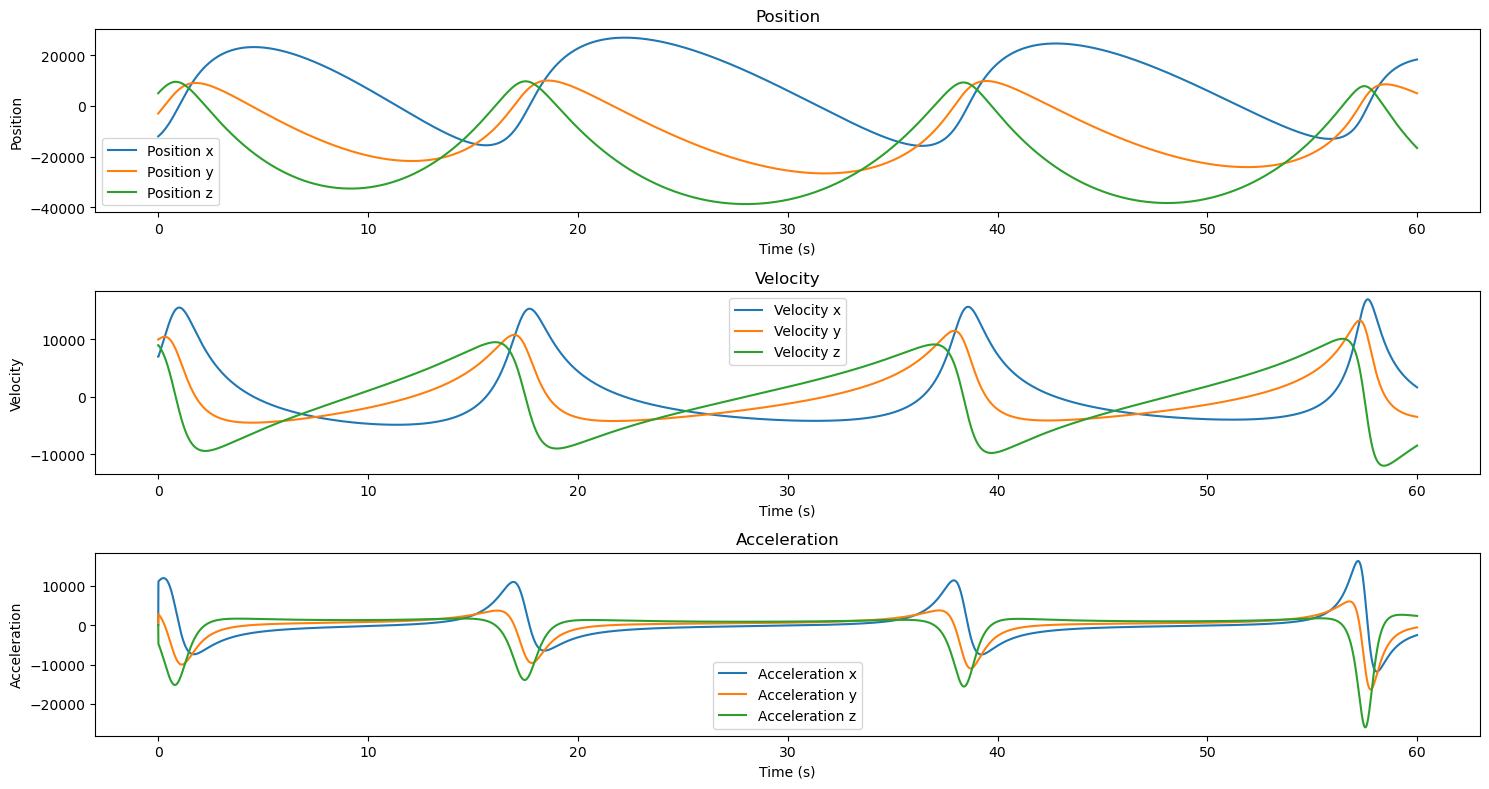

In [61]:
show_plots(raw_data)

We obtained graphs consistent with the conducted simulation:

- The spaceship's position is **non-linear** in function of time, with its velocity (i.e., the first derivative) also not describable as linear.
- The spaceship's acceleration varies as a function of its distance from the Moon: at farther points, the gravitational attraction will be low, while as it gets closer to the Moon, the acceleration will become much stronger (as described by the law of universal gravitation).In particular, it shows "peaks" immediately followed by "troughs": the spaceship go to the moon, but then "overshoots it", hence inversing the pull's direction.

## ADDING NOISE


Lastly, we add Gaussian noise with a standard deviation of σ=1000 to all coefficients of the real values.

Then, we write the resulting noisy values to a file.

In [62]:

noisy_data = add_noise(raw_data)
save_states(noisy_data,'../data/orbiting_noisy.csv')

show_noise(noisy_data)

States saved as rows in '../data/orbiting_noisy.csv'

